In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Bayesian Computation

Everything we have trained so far ends the same way: optimization hands us
one parameter vector, and from then on we act as if it were the truth.
Maximum likelihood picks the single $\boldsymbol\theta$ that best explains
the data; MAP (that section) tempers it with a prior
but still picks one point. When data are plentiful this is hard to beat. But
when data are scarce, when predictions feed decisions with asymmetric costs
— a medical call, a trading position, an autonomous-vehicle brake — or when
we must say *how sure* we are, a single point is an overstatement. Many
quite different parameter vectors explain 80 observations about equally
well, and they disagree about the next prediction. Bayesian prediction requires
averaging over them, weighted by how plausible each remains after seeing the
data. That weighting is exactly the posterior, and the average is the
**posterior predictive**

$$
p(y_\star\mid\mathbf x_\star,\mathcal D)
=\int p(y_\star\mid\mathbf x_\star,\boldsymbol\theta)\,
       p(\boldsymbol\theta\mid\mathcal D)\,d\boldsymbol\theta.
$$

Here is the catch: outside the conjugate families of
that section, this integral — and the posterior's own
normalizer — has no closed form. We can *evaluate* the posterior at any
point, up to an unknown constant, but we cannot *integrate* it. So the whole
of Bayesian practice hinges on one computational question:

> **How do you average over a distribution you can only evaluate pointwise,
> up to a constant?**

**Bayesian computation** is the collection of answers, and this notebook
develops the four that matter most, each embodying a different idea. Sample
somewhere easy and *reweight* (importance sampling). *Walk* through
parameter space so that time spent equals posterior mass (Markov chain Monte
Carlo). Fit a *Gaussian at the peak* and integrate that instead (the Laplace
approximation). Turn integration into *optimization* over a family of
tractable distributions (variational inference). These are not museum
pieces: variational inference is how VAEs and diffusion models are trained,
Laplace and its relatives power practical uncertainty estimates for neural
networks, and MCMC remains the reference answer everything else is checked
against.

One small Bayesian logistic-regression problem runs through the whole
notebook. Because it has only two parameters, a dense grid supplies an
essentially exact posterior against which every approximation can be
audited — a luxury real problems never offer, which is precisely why it is
the right training ground. Conjugate posteriors are treated in
that section; MAP and the ELBO are developed in
that section; differentiation through random
variables is in that section.
Standard broader references are @Bishop.2006 and
@Murphy.2022 . All computation is plain NumPy.

In [1]:
%matplotlib inline
from d2l import tensorflow as d2l
import numpy as np

## The Target: A Posterior Distribution

### A Nonconjugate Running Example

Why logistic regression? Because it is the smallest model where the problem
is real. One Gaussian observation with a Gaussian prior stays Gaussian —
conjugacy hands us the posterior for free. Replace the Gaussian likelihood
with a sigmoid and the gift is withdrawn: no prior matches a logistic
likelihood, and the posterior is a genuinely new function we can evaluate
but not integrate. Every classifier in this book lives on the far side of
that line, so this is the right miniature.

For binary observations $y_i\in\{0,1\}$ and scalar features $x_i$, logistic
regression writes

$$
P(y_i=1\mid x_i,\boldsymbol\theta)
=\sigma(\theta_0+\theta_1x_i),
\qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Put an independent zero-mean Gaussian prior with variance $\tau^2$ on the
intercept and slope. Bayes' rule gives

$$
p(\boldsymbol\theta\mid\mathcal D)
\propto
\left[\prod_{i=1}^n
 \sigma(\mathbf z_i^\top\boldsymbol\theta)^{y_i}
 (1-\sigma(\mathbf z_i^\top\boldsymbol\theta))^{1-y_i}\right]
\exp\!\left(-\frac{\|\boldsymbol\theta\|^2}{2\tau^2}\right),
$$

where $\mathbf z_i=(1,x_i)^\top$. The suppressed normalizer — the
**evidence** $p(\mathcal D)$ — is an integral over $\boldsymbol\theta$ that
we do not know. Notice what we *can* still do cheaply: compare any two
parameter values (the constant cancels in the ratio) and compute gradients
of the log posterior. Every method below is built from exactly these two
operations, which is what makes them general.

The cell creates a small dataset and implements the log of the unnormalized
posterior. `logaddexp` evaluates $\log(1+e^z)$ without overflowing.

In [2]:
rng = np.random.default_rng(12)
n_bayes = 80
x_bayes = rng.uniform(-2.5, 2.5, n_bayes)
Z_bayes = np.column_stack([np.ones(n_bayes), x_bayes])
theta_true = np.array([-0.4, 1.3])
prior_var = 4.0

def sigmoid(z):
    return np.exp(-np.logaddexp(0.0, -z))

p_true = sigmoid(Z_bayes @ theta_true)
y_bayes = rng.binomial(1, p_true)

def log_joint(theta):
    """log p(data, theta), up to a constant; theta has final dimension 2."""
    theta = np.asarray(theta)
    logits = np.einsum('...d,nd->...n', theta, Z_bayes)
    log_lik = (y_bayes * logits - np.logaddexp(0.0, logits)).sum(axis=-1)
    log_prior = -0.5 * (theta**2).sum(axis=-1) / prior_var
    return log_lik + log_prior

def grad_log_joint(theta):
    theta = np.atleast_2d(theta)
    probs = sigmoid(theta @ Z_bayes.T)
    return (y_bayes - probs) @ Z_bayes - theta / prior_var

### A Grid as a Reference, Not a General Algorithm

With two parameters we can cheat: evaluate the log posterior on a dense
grid, exponentiate stably, and normalize the sum. This is deterministic
quadrature — excellent for auditing a two-parameter example, hopeless in
general, because with $m$ points per coordinate a $d$-dimensional grid
costs $m^d$ evaluations. That exponential wall is the same curse of
dimensionality that motivated Monte Carlo integration in
that section, and it is why the rest of this notebook
exists: every method below is a way of spending evaluations only where the
posterior actually has mass, instead of tiling all of parameter space.

In [3]:
b0 = np.linspace(-2.5, 1.5, 241)
b1 = np.linspace(0.0, 2.8, 241)
B0, B1 = np.meshgrid(b0, b1, indexing='ij')
grid_theta = np.stack([B0.ravel(), B1.ravel()], axis=1)
grid_logp = log_joint(grid_theta)
grid_weight = np.exp(grid_logp - grid_logp.max())
grid_weight /= grid_weight.sum()
posterior_mean = grid_weight @ grid_theta
centered = grid_theta - posterior_mean
posterior_cov = (centered * grid_weight[:, None]).T @ centered
print('grid posterior mean:', posterior_mean.round(4))
print('grid posterior sd  :', np.sqrt(np.diag(posterior_cov)).round(4))
print('grid correlation   :',
      round(posterior_cov[0, 1] /
            np.sqrt(posterior_cov[0, 0] * posterior_cov[1, 1]), 4))

grid posterior mean: [-0.3335  1.4794]
grid posterior sd  : [0.3353 0.2871]
grid correlation   : -0.2288


### What Averaging Buys: Mean, MAP, and Prediction

Before approximating the posterior, let us see what keeping it actually
changes. Two candidate summaries compete: the **posterior mean** (an
average) and the **MAP** (the single most probable point). To compare them,
compute the MAP by Newton iteration; the negative Hessian of the log
posterior,

$$
H(\boldsymbol\theta)
=Z^\top\operatorname{diag}(p_i(1-p_i))Z+\tau^{-2}I,
$$

is positive definite thanks to the Gaussian prior, and — keep it in hand —
its inverse at the MAP will become the Laplace approximation below.

In [4]:
theta_map = np.zeros(2)
for _ in range(12):
    probs = sigmoid(Z_bayes @ theta_map)
    precision = (Z_bayes.T @ (Z_bayes * (probs * (1 - probs))[:, None])
                 + np.eye(2) / prior_var)
    theta_map += np.linalg.solve(precision, grad_log_joint(theta_map)[0])
probs = sigmoid(Z_bayes @ theta_map)
laplace_precision = (Z_bayes.T @
                     (Z_bayes * (probs * (1 - probs))[:, None])
                     + np.eye(2) / prior_var)
laplace_cov = np.linalg.inv(laplace_precision)
print('MAP                 :', theta_map.round(4))
print('posterior mean      :', posterior_mean.round(4))

x_new = np.array([-2.0, 0.0, 2.0])
Z_new = np.column_stack([np.ones(len(x_new)), x_new])
pred_grid = grid_weight @ sigmoid(grid_theta @ Z_new.T)
pred_map = sigmoid(Z_new @ theta_map)
for x0, pm, pp in zip(x_new, pred_map, pred_grid):
    print(f'x={x0:+.1f}: plug-in MAP={pm:.3f}, posterior predictive={pp:.3f}')

MAP                 : [-0.3134  1.4039]
posterior mean      : [-0.3335  1.4794]
x=-2.0: plug-in MAP=0.042, posterior predictive=0.044
x=+0.0: plug-in MAP=0.422, posterior predictive=0.420
x=+2.0: plug-in MAP=0.924, posterior predictive=0.923


The two prediction columns differ, and in this example the posterior
predictive is pulled toward $\tfrac12$ relative to the plug-in. The reason is
that the sigmoid is nonlinear, and averaging a nonlinear function is not the
same as applying it to an average — some plausible parameter vectors predict
confidently one way, some the other, and posterior averaging hedges between
them. Here the plug-in predictions are more extreme because they omit
parameter uncertainty. The gap closes as the posterior
concentrates with more data, but at $n=80$ it is visibly there, and this
single effect is the practical payoff that justifies everything that
follows.

## Importance Sampling: Correcting a Proposal

We cannot draw samples from the posterior. But we can draw from *something
else* — a Gaussian, say — and no law forbids using those draws, as long as
we account for the mismatch. A draw that lands where the proposal
over-represents the posterior should count for less; one landing where the
proposal under-represents it should count for more. "How much less or
more" is just the density ratio. That single idea — sample from the wrong
distribution, then reweight by right-over-wrong — is **importance
sampling**, and it turns the unknown integral into two averages we can
estimate. If $q$ is a normalized proposal we can sample and evaluate, and
$\widetilde p(\boldsymbol\theta)=p(\mathcal D,\boldsymbol\theta)$ is our
evaluable unnormalized target, then

$$
\mathbb E_{p(\boldsymbol\theta\mid\mathcal D)}[h(\boldsymbol\theta)]
=
\frac{\mathbb E_q[w(\boldsymbol\theta)h(\boldsymbol\theta)]}
     {\mathbb E_q[w(\boldsymbol\theta)]},
\qquad
w(\boldsymbol\theta)=\frac{\widetilde p(\boldsymbol\theta)}
                           {q(\boldsymbol\theta)}.
$$

Dividing by the average weight is what disposes of the unknown normalizer —
it appears in numerator and denominator and cancels. Replacing both
expectations by sample averages gives **self-normalized importance
sampling**: consistent, though slightly biased at finite $N$ because it is
a ratio of random quantities. As always with products of many likelihood
terms, the computation belongs in log space with a max subtracted, exactly
like log-sum-exp.

Everything therefore rides on one question: *where does the proposal put
its draws?* the figure shows the failure mode
and, more disturbingly, how it hides.

![Importance sampling stands or falls with proposal coverage. Both panels reweight 24 draws from a Gaussian proposal (dashed) against the same two-mode target (solid); stems show the normalized weights. Left: a narrow proposal never samples the right-hand mode, so the weights are blind to it — yet the effective sample size looks nearly perfect. Right: a proposal that covers the target yields well-distributed weights and trustworthy estimates.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-bayes-importance.svg)

The standard health check is the weight **effective sample size**

$$
N_{\mathrm{eff}}=\frac{1}{\sum_{s=1}^N\bar w_s^2},
\qquad
\bar w_s=\frac{w_s}{\sum_r w_r},
$$

which lies between $1$ (one draw carries everything) and $N$ (all draws
count equally) and measures how concentrated the weights are.
the figure is a warning about its limits: the
left panel's ESS is excellent *because* the proposal never found the second
mode. ESS can detect weights that are unequal; it cannot detect mass that
was never sampled.

On our logistic posterior we compare two Gaussian proposals: the broad
prior, and the local Gaussian built from the MAP and inverse Hessian
computed above (the Laplace approximation, formalized below, here playing
its other standard role — as a proposal generator).

In [5]:
def gaussian_logpdf(samples, mean, cov):
    diff = samples - mean
    sign, logdet = np.linalg.slogdet(cov)
    precision = np.linalg.inv(cov)
    return -0.5 * (len(mean) * np.log(2 * np.pi) + logdet
                   + np.einsum('ni,ij,nj->n', diff, precision, diff))

def importance(proposal_mean, proposal_cov, n, seed):
    local_rng = np.random.default_rng(seed)
    samples = local_rng.multivariate_normal(proposal_mean, proposal_cov, n)
    logw = log_joint(samples) - gaussian_logpdf(
        samples, proposal_mean, proposal_cov)
    weight = np.exp(logw - logw.max())
    weight /= weight.sum()
    mean = weight @ samples
    predictive = weight @ sigmoid(samples @ Z_new.T)
    ess = 1.0 / (weight @ weight)
    return mean, predictive, ess, weight.max()

prior_is = importance(np.zeros(2), prior_var * np.eye(2), 20000, 2)
laplace_is = importance(theta_map, laplace_cov, 5000, 3)
for name, result, n in [('prior proposal', prior_is, 20000),
                        ('Laplace proposal', laplace_is, 5000)]:
    mean, pred, ess, max_weight = result
    print(f'{name:18s}: ESS={ess:7.1f}/{n}, max weight={max_weight:.4f}, '
          f'mean={mean.round(4)}')

prior proposal    : ESS=  681.1/20000, max weight=0.0029, mean=[-0.3415  1.4898]
Laplace proposal  : ESS= 4287.3/5000, max weight=0.0025, mean=[-0.3359  1.4772]


The prior proposal spends most of its 20,000 draws where the posterior is
negligible — that is what its low ESS is reporting — while the Laplace
proposal, aimed at the posterior, extracts more usable information from a
quarter as many draws. This posterior is unimodal and nearly Gaussian, so
the story ends well; in high dimension or under mode mismatch the weights
degenerate rapidly, and the variance of the weights, not the nominal draw
count, sets how much you actually learned.

## Markov Chain Monte Carlo

Importance sampling makes one global guess about where the posterior lives
and pays dearly when the guess is off. The next idea abandons guessing for
*exploration*: start anywhere, take small steps, and bias the steps so
that, in the long run, the walker's location is distributed exactly as the
posterior — time spent in a region proportional to the probability mass it
holds. Then the chain's states *are* posterior samples (dependent ones),
and averaging over the trajectory approximates
the equation. This is **Markov chain Monte Carlo**, and
the miracle is how little the walking rule needs to know: only posterior
*ratios* between the current point and a proposed one — precisely the
quantity that survives the unknown normalizer.

The **Metropolis** rule makes the bias concrete: from
$\boldsymbol\theta$, propose
$\boldsymbol\theta'\sim q(\cdot\mid\boldsymbol\theta)$; if the proposal is
uphill ($\widetilde p$ increases), accept it always; if it is downhill,
accept it with probability equal to the ratio $\widetilde
p(\boldsymbol\theta')/\widetilde p(\boldsymbol\theta)$ — otherwise stay
put. In general, with an asymmetric proposal,

$$
\alpha(\boldsymbol\theta,\boldsymbol\theta')
=\min\!\left(1,
\frac{\widetilde p(\boldsymbol\theta')
      q(\boldsymbol\theta\mid\boldsymbol\theta')}
     {\widetilde p(\boldsymbol\theta)
      q(\boldsymbol\theta'\mid\boldsymbol\theta)}\right).
$$

Why does always-up, sometimes-down produce the right distribution and not
just a hill-climber? Because the occasional accepted downhill move is
calibrated *exactly*: the acceptance ratio makes the probability flow from
$\boldsymbol\theta$ to $\boldsymbol\theta'$ equal the flow back — a
condition called **detailed balance**. A distribution with no net flow
anywhere has no reason to change, so the posterior is stationary: once the
chain is distributed as the posterior it stays that way, and under mild
conditions it converges there from any start. Two bookkeeping consequences
follow directly: rejected proposals are not discarded — the repeated state
is what "spending more time where mass is high" looks like — and the
normalizer never appears, having cancelled in the ratio.

![A Metropolis random walk on posterior contours. From the starting square, each step proposes a local move; uphill moves are always accepted (path), downhill moves only sometimes — a rejected proposal (crosses) leaves the chain in place for another step. In the long run the time the walk spends in a region is proportional to its posterior mass.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-bayes-metropolis.svg)

The cell runs four chains from dispersed starts, using the Laplace
covariance only to scale and orient the proposal — the Metropolis
correction, not that Gaussian, determines the stationary distribution.

In [6]:
def metropolis(start, proposal_chol, n_steps, seed):
    local_rng = np.random.default_rng(seed)
    current = np.array(start, dtype=float)
    current_logp = log_joint(current)
    draws = np.empty((n_steps, 2))
    accepted = 0
    for t in range(n_steps):
        proposal = current + proposal_chol @ local_rng.standard_normal(2)
        proposal_logp = log_joint(proposal)
        if np.log(local_rng.random()) < proposal_logp - current_logp:
            current, current_logp = proposal, proposal_logp
            accepted += 1
        draws[t] = current
    return draws, accepted / n_steps

starts = np.array([[-2.0, 0.0], [1.0, 0.3], [-1.0, 2.5], [1.0, 2.5]])
proposal_chol = 1.1 * np.linalg.cholesky(laplace_cov)
chains = []
for c, start in enumerate(starts):
    chain, accept_rate = metropolis(start, proposal_chol, 12000, 20 + c)
    chains.append(chain[2000:])                 # discard the initial transient
    print(f'chain {c + 1}: acceptance rate={accept_rate:.3f}')
chains = np.asarray(chains)

chain 1: acceptance rate=0.525
chain 2: acceptance rate=0.526


chain 3: acceptance rate=0.526
chain 4: acceptance rate=0.527


### Diagnostics: Mixing, Not Just Draw Count

The price of exploration is dependence: consecutive states are correlated,
so a chain of $10{,}000$ states holds far less information than $10{,}000$
independent draws — how much less depends on how fast the walk forgets
where it was. Because the chain also starts wherever we put it, we need
evidence that it has both *forgotten its start* and *slowed to the right
pace*. Three checks answer different questions:

* **Trace plots** reveal sticking, drift, and chains that disagree —
  the failures visible to the naked eye.
* **Split $\widehat R$** compares within-chain and between-chain variation;
  values near one are necessary (not sufficient) for convergence: if
  chains from dispersed starts still disagree, none of them can be
  trusted.
* **Effective sample size** converts autocorrelation into an equivalent draw
  count: with autocorrelation time $\tau=1+2\sum_{k\ge1}\rho_k$, $M$
  chains of length $N$ contain about $MN/\tau$ draws' worth of
  information, and the Monte Carlo standard error of a posterior mean is
  roughly the posterior standard deviation over
  $\sqrt{N_{\mathrm{eff}}}$.

The implementations below are intentionally transparent teaching versions;
production software uses rank-normalized split $\widehat R$, bulk and tail
ESS, and more careful truncation of the autocorrelation sum.

split R-hat: [1.0008 1.0004]
ESS        : [4521 4098]
MCMC mean  : [-0.3317  1.4768]   grid mean: [-0.3335  1.4794]
MCSE       : [0.005  0.0044]


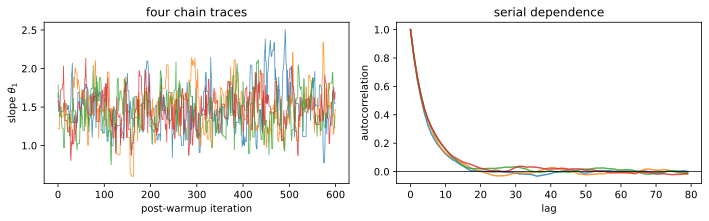

In [7]:
def split_rhat(x):
    m, n, d = x.shape
    half = n // 2
    split = np.concatenate([x[:, :half], x[:, half:2 * half]], axis=0)
    within = split.var(axis=1, ddof=1).mean(axis=0)
    between = half * split.mean(axis=1).var(axis=0, ddof=1)
    variance = (half - 1) * within / half + between / half
    return np.sqrt(variance / within)

def autocorrelation(x):
    x = x - x.mean()
    n = len(x)
    spectrum = np.fft.rfft(x, n=2 * n)
    acov = np.fft.irfft(spectrum * np.conj(spectrum))[:n]
    return acov / acov[0]

def teaching_ess(x):
    m, n, d = x.shape
    result = []
    for j in range(d):
        rho = np.mean([autocorrelation(x[c, :, j]) for c in range(m)], axis=0)
        positive_pairs = 0.0
        for lag in range(1, n - 1, 2):
            pair = rho[lag] + rho[lag + 1]
            if pair < 0:
                break
            positive_pairs += pair
        result.append(m * n / (1 + 2 * positive_pairs))
    return np.asarray(result)

d2l.use_svg_display()
flat_chains = chains.reshape(-1, 2)
rhat = split_rhat(chains)
ess = teaching_ess(chains)
mcmc_mean = flat_chains.mean(axis=0)
mcmc_sd = flat_chains.std(axis=0, ddof=1)
print('split R-hat:', rhat.round(4))
print('ESS        :', ess.round(0).astype(int))
print('MCMC mean  :', mcmc_mean.round(4),
      '  grid mean:', posterior_mean.round(4))
print('MCSE       :', (mcmc_sd / np.sqrt(ess)).round(4))

fig, axes = d2l.plt.subplots(1, 2, figsize=(10, 3.2))
for c in range(len(chains)):
    axes[0].plot(chains[c, :600, 1], linewidth=0.8, alpha=0.8)
axes[0].set(xlabel='post-warmup iteration', ylabel=r'slope $\theta_1$',
            title='four chain traces')
for c in range(len(chains)):
    axes[1].plot(autocorrelation(chains[c, :, 1])[:80], alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].set(xlabel='lag', ylabel='autocorrelation', title='serial dependence')
d2l.plt.tight_layout()
d2l.plt.show()

Acceptance rate alone is not a convergence diagnostic: tiny proposals
accept nearly everything while crawling, huge ones are mostly rejected. Nor
does discarding a longer "burn-in" repair poor mixing. Run multiple chains,
inspect the quantities you care about, and report ESS and Monte Carlo error
alongside every posterior estimate.

Metropolis is the smallest useful MCMC algorithm, not the last word.
**Gibbs sampling** exploits models whose conditionals are tractable,
sampling one block at a time. **Hamiltonian Monte Carlo** uses the gradient
of the log posterior to make long, directed moves (the No-U-Turn Sampler
adapts their length), mixing dramatically faster in correlated
high-dimensional posteriors. Both inherit the same workflow: multiple
chains, geometry-aware tuning, and the diagnostics above.

## Deterministic Approximations

Sampling spends compute at prediction time. The alternative is to spend it
once, up front: replace the awkward posterior by the *nearest tractable
distribution* $q$, then integrate against $q$ in closed form forever after.
The two classical instantiations differ in what "nearest" means — and both
reuse machinery we already have: optimization from
that section, Taylor expansion, and the ELBO.

### Laplace: the Free Gaussian in Every MAP

Training already finds the MAP; the Laplace approximation observes that the
mode's neighborhood contains more reusable information. Expand the log
posterior to second order about $\boldsymbol\theta_{\mathrm{MAP}}$: the
linear term vanishes at a maximum, so locally the log posterior is a
downward parabola — and a distribution whose log is a parabola is a
Gaussian. With $H$ the negative Hessian at the mode,

$$
p(\boldsymbol\theta\mid\mathcal D)
\approx\mathcal N(\boldsymbol\theta_{\mathrm{MAP}},H^{-1}),
$$

which costs one Hessian beyond the optimization you were doing anyway —
that is its enduring appeal, from classical statistics to
uncertainty-for-deep-networks toolboxes, where $H$ is further approximated
(diagonal, Kronecker-factored, last-layer-only) to scale.

![The Laplace approximation is a quadratic fit to the log posterior at its mode. Left: the fit matches value, slope, and curvature at the mode and nothing else. Right: after exponentiating, the implied Gaussian reproduces the peak's location and width but misses the skew — too much mass on one side, a dropped tail on the other.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-bayes-laplace.svg)

the figure shows exactly what is kept and what is
lost: location and curvature survive; skewness, heavy tails, boundaries,
and any second mode do not — the approximation is *local* by construction.
In our running example the effect is mild but visible: the Laplace mean
*is* the MAP, while the true posterior mean sits slightly away from it,
shifted by the skew the parabola cannot see.

### Variational Inference: Integration Becomes Optimization

The Laplace approximation lets the mode dictate the Gaussian. Variational
inference instead *searches* for the best tractable approximation: fix a
family $q_\phi$ (here, Gaussians), define "best" as minimal
$D_{\mathrm{KL}}(q_\phi\,\|\,p(\cdot\mid\mathcal D))$, and optimize
$\phi$. That KL still contains the unknown evidence — but only as an
additive constant, so maximizing the **ELBO**

$$
\mathcal L(\phi)
=\mathbb E_{q_\phi}
 [\log p(\mathcal D,\boldsymbol\theta)-\log q_\phi(\boldsymbol\theta)]
\le\log p(\mathcal D)
$$

is the same problem, and every term in it is computable. This maneuver —
trading an integral for an optimization over distributions — is the single
most consequential idea in modern approximate inference: with
$q_\phi$ produced by a neural network it is the training objective of the
VAE, and the same bound underlies diffusion-model training.

The choice of KL direction has teeth, and
the figure shows them. Reverse KL charges $q$
infinitely for placing mass where $p$ has none, so when the family is too
simple to cover everything, the optimum *retreats into one mode* and
reports confident, too-narrow uncertainty. The forward direction (used by
expectation propagation and moment matching) makes the opposite error,
smearing mass across the valley. Neither is "wrong" — they answer
different questions — but you should know which failure you have signed up
for: variational inference is the mode-seeking one.

![The direction of the KL divergence decides how a too-simple approximation fails. For a two-mode target, the best reverse-KL Gaussian — what variational inference optimizes — locks onto a single mode and understates uncertainty, while the best forward-KL Gaussian covers the mass of both modes at the price of putting its bulk where the target is small.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-bayes-kl-modes.svg)

To optimize the ELBO we need its gradient, and here the reparameterization
trick of that section earns its
keep. Take a mean-field Gaussian
$q=\mathcal N(\mathbf m,\operatorname{diag}(\mathbf s^2))$ and write
$\boldsymbol\theta=\mathbf m+\mathbf s\odot\boldsymbol\epsilon$ with
$\boldsymbol\epsilon\sim\mathcal N(\mathbf 0,\mathbf I)$; gradients then
flow through the sample:

$$
\nabla_{\mathbf m}\mathcal L
=\mathbb E[\nabla_{\boldsymbol\theta}\log p(\mathcal D,\boldsymbol\theta)],
\qquad
\nabla_{\log\mathbf s}\mathcal L
=\mathbb E[\nabla_{\boldsymbol\theta}\log p
 \odot\mathbf s\odot\boldsymbol\epsilon]+\mathbf1,
$$

where the $+\mathbf1$ is the Gaussian entropy derivative. The cell
optimizes these one-sample-batch estimates with a small Adam loop in plain
NumPy — the same optimizer loop you have used all book, applied to a
distribution instead of a network.

In [8]:
rng_vi = np.random.default_rng(31)
m_vi = theta_map.copy()
log_s_vi = np.log(np.sqrt(np.diag(laplace_cov)))
m1 = np.zeros(2); v1 = np.zeros(2)
m2 = np.zeros(2); v2 = np.zeros(2)
for t in range(1, 1501):
    eps = rng_vi.standard_normal((256, 2))
    s_vi = np.exp(log_s_vi)
    theta_vi = m_vi + eps * s_vi
    grad_theta = grad_log_joint(theta_vi)
    grad_m = grad_theta.mean(axis=0)
    grad_log_s = (grad_theta * eps * s_vi).mean(axis=0) + 1.0
    for grad, param, first, second in [
            (grad_m, m_vi, m1, v1), (grad_log_s, log_s_vi, m2, v2)]:
        first *= 0.9
        first += 0.1 * grad
        second *= 0.999
        second += 0.001 * grad**2
        first_hat = first / (1 - 0.9**t)
        second_hat = second / (1 - 0.999**t)
        param += 0.03 * first_hat / (np.sqrt(second_hat) + 1e-8)

vi_cov = np.diag(np.exp(2 * log_s_vi))
print('method       mean                 marginal sd')
print('grid      ', posterior_mean.round(4), np.sqrt(np.diag(posterior_cov)).round(4))
print('Laplace   ', theta_map.round(4), np.sqrt(np.diag(laplace_cov)).round(4))
print('mean-field', m_vi.round(4), np.exp(log_s_vi).round(4))

method       mean                 marginal sd
grid       [-0.3335  1.4794] [0.3353 0.2871]
Laplace    [-0.3134  1.4039] [0.3256 0.2746]
mean-field [-0.2958  1.4816] [0.3233 0.2733]


Both failure modes predicted above are on display. Mean-field's diagonal
covariance cannot represent the posterior's intercept–slope correlation at
all, and reverse KL prefers a slightly too-concentrated fit over leaking
mass into low-posterior regions. A richer family — full covariance, a
normalizing flow, a mixture — buys back fidelity at more optimization and
implementation cost. And a stabilized ELBO means one optimization run has
settled, not that the family was adequate: validate against predictions,
not against the objective.

The final picture overlays everything this notebook has produced on the
grid reference: exact contours, Metropolis draws, and the two Gaussian
approximations.

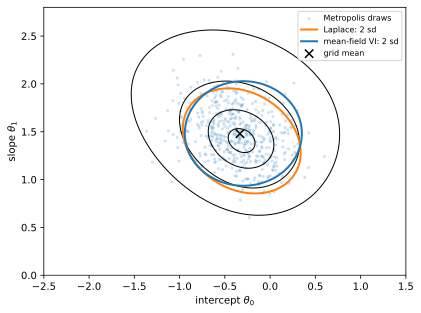

In [9]:
def covariance_ellipse(mean, cov, color, label):
    values, vectors = np.linalg.eigh(cov)
    angle = np.linspace(0, 2 * np.pi, 240)
    circle = np.stack([np.cos(angle), np.sin(angle)])
    ellipse = mean[:, None] + vectors @ (2 * np.sqrt(values)[:, None] * circle)
    d2l.plt.plot(ellipse[0], ellipse[1], color=color, linewidth=2, label=label)

d2l.plt.figure(figsize=(6, 4.5))
levels = np.quantile(grid_weight, [0.70, 0.90, 0.97, 0.995])
d2l.plt.contour(B0, B1, grid_weight.reshape(B0.shape),
                levels=np.unique(levels), colors='black', linewidths=1)
d2l.plt.scatter(flat_chains[::80, 0], flat_chains[::80, 1], s=5, alpha=0.15,
                label='Metropolis draws')
covariance_ellipse(theta_map, laplace_cov, 'tab:orange', 'Laplace: 2 sd')
covariance_ellipse(m_vi, vi_cov, 'tab:blue', 'mean-field VI: 2 sd')
d2l.plt.scatter(*posterior_mean, marker='x', s=70, color='black',
                label='grid mean')
d2l.plt.xlabel(r'intercept $\theta_0$')
d2l.plt.ylabel(r'slope $\theta_1$')
d2l.plt.legend(fontsize=8)
d2l.plt.tight_layout()
d2l.plt.show()

The Metropolis cloud traces the exact contours, skew included; the Laplace
ellipse is centered at the MAP with roughly the right shape; the mean-field
ellipse is axis-aligned — it *cannot* tilt — and slightly small. One plot,
all four trade-offs.

## A Practical Decision Map

The methods answer the same question with different failure modes.

| Method | Representation | Main diagnostic | Characteristic failure |
|---|---|---|---|
| Conjugacy / exact algebra | closed-form distribution | algebra and numerical checks | available only for special model--prior pairs |
| Grid / quadrature | weighted deterministic points | resolution and domain expansion | exponential cost in dimension |
| Importance sampling | independent weighted draws | weight ESS, largest weights, repeated runs | proposal misses or barely covers posterior mass |
| MCMC | dependent posterior draws | traces, split $\widehat R$, ESS, MCSE | poor mixing, undiscovered modes, bad geometry |
| Laplace | one local Gaussian | comparison with samples or sensitivity to mode | skewness, tails, boundaries, multiple modes |
| Variational inference | optimized tractable $q_\phi$ | ELBO, repeated starts, predictive checks | family restriction and local optima; biased uncertainty |

A robust workflow starts with the estimand: posterior mean, predictive
probability, tail event, or decision. Use exact conjugacy when available;
use a grid only as a low-dimensional check. For MCMC, run multiple chains
and budget by ESS rather than iterations. For importance sampling, inspect
weights. For Laplace and VI, test the approximation on posterior predictive
quantities and, when feasible, compare a subset against MCMC. No scalar
diagnostic proves that an unseen mode does not exist —
the figure is this notebook's standing
reminder.

One notebook is enough for this computational bridge because the shared
target and reference grid make the methods comparable. It is not a full
Bayesian curriculum: hierarchical models, Gibbs derivations, HMC/NUTS,
sequential Monte Carlo, model comparison, and predictive checking each
deserve more space once the book needs them operationally.

## Summary

* Bayesian inference averages predictions over the posterior; the payoff is
  calibrated uncertainty — plug-in point estimates are systematically
  overconfident because a nonlinear function of an average is not the
  average of the function.
* Everything is built from two cheap operations: evaluating the
  unnormalized posterior and its gradient. The unknown normalizer always
  cancels — in importance ratios, in Metropolis acceptances, in the ELBO.
* Importance sampling reweights draws from a wrong-but-easy proposal;
  coverage is everything, and weight ESS cannot see mass that was never
  sampled.
* Metropolis explores: always accept uphill, accept downhill in exact
  proportion — detailed balance makes time spent proportional to posterior
  mass. Judge chains by mixing (traces, split $\widehat R$, ESS, MCSE),
  never by acceptance rate alone.
* Laplace is the free Gaussian hiding in every MAP fit — right location
  and curvature, blind to skew, tails, and other modes. Variational
  inference turns integration into optimization of the ELBO and inherits
  reverse KL's mode-seeking, too-confident failure mode.

## Exercises

1. Change the prior standard deviation from $2$ to $0.5$ and $10$. Compare the
   MAP, posterior mean, covariance, posterior predictive, and importance-sampling
   ESS. Which quantities are most sensitive at this sample size?
2. Deliberately use an importance proposal with covariance
   $0.05I$. Run ten seeds. Although this Gaussian has full mathematical support,
   explain why a plausible estimate in one run does not repair its poor
   finite-sample coverage of the posterior.
3. Sweep the Metropolis proposal multiplier over
   $\{0.05,0.2,0.5,1.1,3,10\}$. Plot acceptance rate against ESS per log-joint
   evaluation and explain why maximizing acceptance is the wrong objective.
4. Replace the mean-field variational family by a full-covariance Gaussian
   parameterized by a Cholesky factor. Derive a valid parameterization with
   positive diagonal and compare the fitted correlation with the grid value.
5. Create a bimodal one-dimensional posterior by using a likelihood invariant
   under $\theta\mapsto-\theta$. Show how a local Laplace approximation,
   mean-field reverse-KL optimization, and poorly initialized MCMC can each
   report only one mode. Which diagnostics reveal the problem, and which do not?